In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
train_path = "../data/raw/train"
valid_path = "../data/raw/val"

In [5]:
classes = os.listdir(train_path)

print("Total classes: ", len(classes))
print(classes)

Total classes:  10
['Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold']


In [6]:
first_class = classes[0]
class_path = os.path.join(train_path, first_class)
image_name = os.listdir(class_path)[0]
image_path = os.path.join(class_path, image_name)

img = cv2.imread(image_path)

print("Image shape: ", img.shape)

Image shape:  (256, 256, 3)


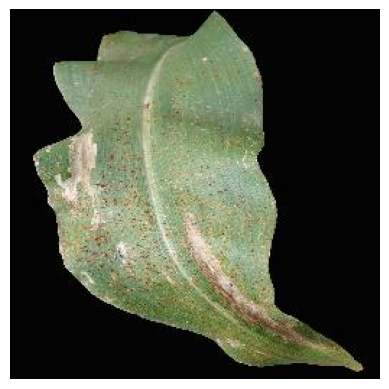

In [7]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
# step 2 Image preprocessing

img = cv2.resize(img, (128,128))    # resizing

img = img / 255.0        # normalize 0 to 1

img = np.expand_dims(img, axis=0)   # cnn model inputs (batch_size, height, width, channels) , to add new dimension in array at which position(axis 0- height, axis 1- width, axis 2- channels) 

print(img.shape)

(1, 128, 128, 3)


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.2, rotation_range=20)
val_gen = ImageDataGenerator(rescale=1./255)



In [10]:
train_data = train_gen.flow_from_directory(train_path, target_size=(128,128), batch_size=32, class_mode= 'categorical')
val_data = val_gen.flow_from_directory(valid_path, target_size=(128,128), batch_size= 32, class_mode= 'categorical')

Found 8908 images belonging to 10 classes.
Found 2230 images belonging to 10 classes.


In [11]:
print(train_data.class_indices)

{'Corn_(maize)___Common_rust_': 0, 'Corn_(maize)___healthy': 1, 'Grape___Black_rot': 2, 'Potato___Early_blight': 3, 'Potato___Late_blight': 4, 'Potato___healthy': 5, 'Tomato___Early_blight': 6, 'Tomato___Late_blight': 7, 'Tomato___Leaf_Mold': 8, 'Tomato___healthy': 9}


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(train_data.class_indices)
print("Number of classes: ", num_classes)

model = Sequential()

# Convolutional layers 1
model.add(Conv2D(32, (3,3), activation= 'relu', input_shape=(128, 128, 3)))

# Pooling 
model.add(MaxPooling2D((2,2)))

# Convolutional layers 2
model.add(Conv2D(64, (3,3), activation = 'relu'))

# Pooling
model.add(MaxPooling2D((2,2)))

# Convolutional layers 3
model.add(Conv2D(128,(3,3), activation= 'relu'))

# Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten 
model.add(Flatten())

# Dense layer 
model.add(Dense(256, activation= 'relu'))

# Dropout
model.add(Dropout(0.3))

# Output layer
model.add(Dense(num_classes, activation= 'softmax'))

Number of classes:  10


In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [14]:
model.compile(optimizer= 'adam', loss= 'categorical_crossentropy', metrics= ['accuracy'])

In [16]:
history = model.fit(train_data, validation_data=val_data, epochs= 10)

Epoch 1/10
279/279 [==============================] - 79s 281ms/step - loss: 0.9781 - accuracy: 0.6524 - val_loss: 0.7162 - val_accuracy: 0.7731
Epoch 2/10
279/279 [==============================] - 76s 273ms/step - loss: 0.5751 - accuracy: 0.8003 - val_loss: 0.3858 - val_accuracy: 0.8601
Epoch 3/10
279/279 [==============================] - 76s 272ms/step - loss: 0.3544 - accuracy: 0.8778 - val_loss: 0.3609 - val_accuracy: 0.8717
Epoch 4/10
279/279 [==============================] - 77s 274ms/step - loss: 0.3250 - accuracy: 0.8884 - val_loss: 0.4370 - val_accuracy: 0.8561
Epoch 5/10
279/279 [==============================] - 79s 282ms/step - loss: 0.2619 - accuracy: 0.9087 - val_loss: 0.4688 - val_accuracy: 0.8583
Epoch 6/10
279/279 [==============================] - 84s 300ms/step - loss: 0.2377 - accuracy: 0.9165 - val_loss: 0.3203 - val_accuracy: 0.9027
Epoch 7/10
279/279 [==============================] - 90s 321ms/step - loss: 0.2277 - accuracy: 0.9189 - val_loss: 0.2756 - val_ac

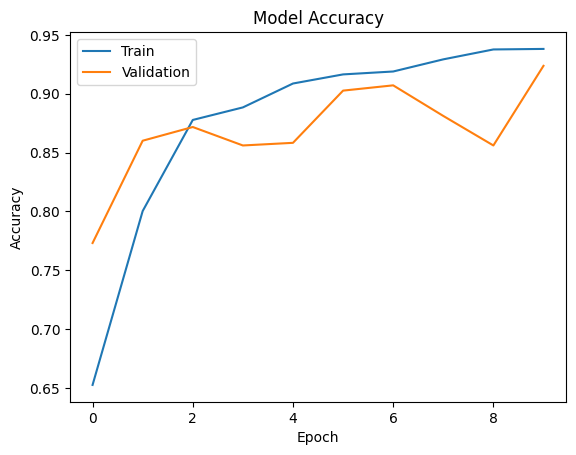

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

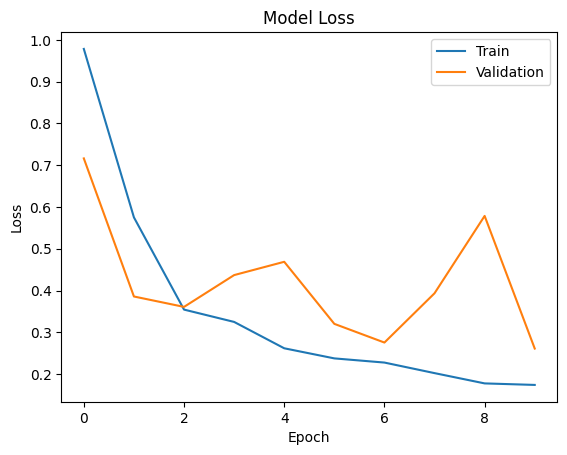

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", 'Validation'])

plt.show()

In [19]:
model.save("plant_disease_model.h5")

In [20]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

model=load_model('plant_disease_model.h5')
print("loaded")


loaded


In [21]:
class_names = list(train_data.class_indices.keys())

print(class_names)

['Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


In [22]:
train_data = train_gen.flow_from_directory(train_path, target_size=(128,128), batch_size=32, class_mode='categorical')
val_data = val_gen.flow_from_directory(valid_path, target_size=(128,128), batch_size=32, class_mode='categorical')

Found 8908 images belonging to 10 classes.
Found 2230 images belonging to 10 classes.


In [23]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


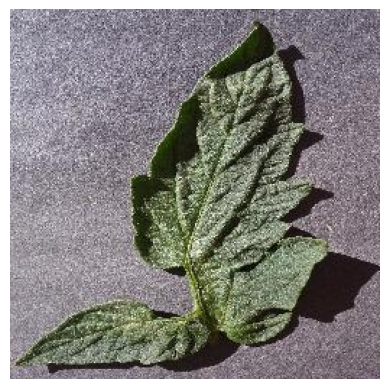

1/1 [==============================] - 0s 271ms/step
Prediction : Tomato___healthy


In [24]:
img_path = "../data/raw/val/Tomato___healthy/0a205a11-1e64-49f7-93c2-ad59312b4f83___RS_HL 0334.JPG"

# read image
img = cv2.imread(img_path)

# convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# show image
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# resize
img = cv2.resize(img_rgb, (128, 128))

# normalize
img = img / 255.0

# add batch dimensions
img = np.expand_dims(img, axis=0)

# prediction 
prediction = model.predict(img)

# predicted index
predicted_class = np.argmax(prediction)

# final prediction 
print("Prediction :", class_names[predicted_class])

In [25]:
import tensorflow as tf
print(tf.__version__)


2.10.0
